In [30]:
# Cargo las librerías básicas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Cargo librerías para el preprocesamiento de datos
from sklearn.model_selection import train_test_split # Dividir los datos en conjuntos de entrenamiento y prueba
from sklearn.preprocessing import StandardScaler # Estandarización de características
from sklearn.impute import SimpleImputer # Manejo de valores faltantes
# Si es necesario, cargo librerías de datasets de ejemplo
#from sklearn.datasets import load_titanic # Dataset del Titanic

# Si es necesario, cargo librerías para la ingeniería de características (Opcional)
from sklearn.preprocessing import OneHotEncoder # Codificación de variables categóricas
# Cargo librerías para la construcción de modelos
from sklearn.tree import DecisionTreeClassifier # Árbol de decisión para clasificación
# Cargo librerías para la evaluación de modelos
from sklearn import metrics # Métricas de evaluación

Variable	Definition	Key
Survived	Survival	
- 0 = No, 1 = Yes
Pclass	Ticket class	
- 1 = 1st, 2 = 2nd, 3 = 3rd
Sex	Sex
Age	Age in years
Sibsp	# of siblings / spouses aboard the Titanic
Parch	# of parents / children aboard the Titanic
Ticket	Ticket number
Fare	Passenger fare
Cabin	Cabin number
Embarked	Port of Embarkation	
- C = Cherbourg, Q = Queenstown,S = Southampton
Pclass: A proxy for socio-economic status (SES)
- 1st = Upper
- 2nd = Middle
- 3rd = Lower

Age: Age is fractional if less than 1. If the age is estimated, is it in the form of xx.5

Sibsp: The dataset defines family relations in this way...
Sibling = brother, sister, stepbrother, stepsister
Spouse = husband, wife (mistresses and fiancés were ignored)

Parch: The dataset defines family relations in this way...
Parent = mother, father
Child = daughter, son, stepdaughter, stepson
Some children travelled only with a nanny, therefore parch=0 for them.

In [6]:
# Obtener el dataset del Titanic
df = pd.read_csv('../datasets/titanic-data.csv', header='infer')

In [13]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## Procesamiento de datos

### Procesamiento de los valores faltantes (nulos)

In [15]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

Tratamiento de las edades nulas

In [11]:
# Estrategia para manejar valores faltantes en la columna 'Age'. Rellenar con la media de la columna.
# edad_media = df['Age'].mean()
# df['Age'].fillna(edad_media, inplace=True)

edades = []
for i in range(len(df)):
    if pd.isnull(df.loc[i, 'Age']):
        if ('Mr' in df['Name'][i]) or ('Mrs' in df['Name'][i]):
            edades.append(33) # Edad media aproximada para Mr y Mrs
        else:
            edades.append(10) # Edad media aproximada para Miss        
    else:
        edades.append(df.loc[i, 'Age']) # Mantener la edad original si no es nula
df['Age'] = edades

Tratamiento de los Embarked faltantes

In [14]:
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True) # Rellenar con la moda de la columna 'Embarked'

C:\Users\Fran\AppData\Local\Temp\ipykernel_44948\880485681.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True) # Rellenar con la moda de la columna 'Embarked'


## Estudio de supervivencia

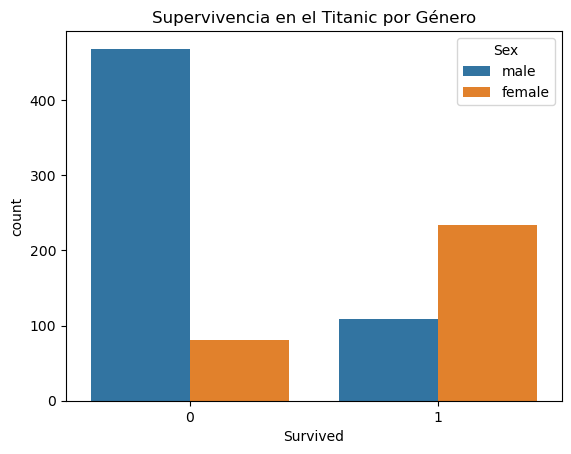

In [ ]:
# Graficar la distribución de supervivencia por género
sns.countplot(x='Survived', data=df, hue='Sex') # Visualizar supervivencia por género
plt.title('Supervivencia en el Titanic por Género')
plt.show()

C:\Users\Fran\AppData\Local\Temp\ipykernel_44948\1632775984.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='EdadCategoria', y='Survived', data=df, ci=None)


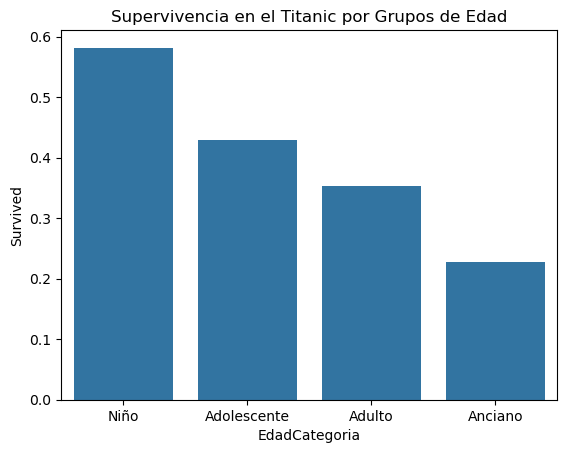

In [19]:
# Graficar la distribución de supervivencia por grupos de edades
df["EdadCategoria"] = pd.cut(df["Age"], bins=[0, 12, 18, 60, 100], labels=["Niño", "Adolescente", "Adulto", "Anciano"])
sns.barplot(x='EdadCategoria', y='Survived', data=df, ci=None)
plt.title('Supervivencia en el Titanic por Grupos de Edad')
plt.show()

C:\Users\Fran\AppData\Local\Temp\ipykernel_44948\3908916897.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='SibSp', y='Survived', data=df, ci=None)


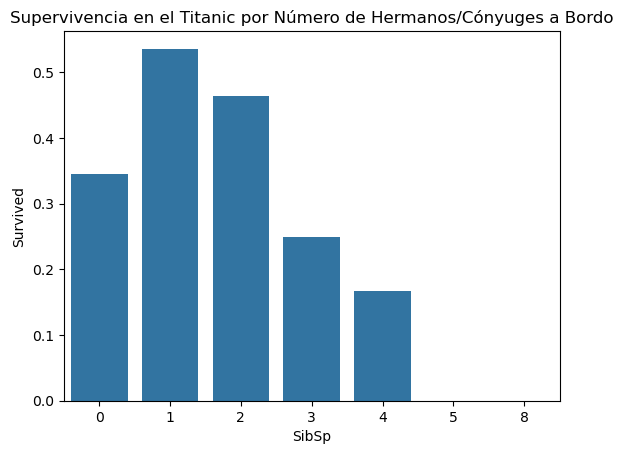

In [20]:
# Supervivencia en el Titanic por número de hermanos/cónyuges a bordo
sns.barplot(x='SibSp', y='Survived', data=df, ci=None)
plt.title('Supervivencia en el Titanic por Número de Hermanos/Cónyuges a Bordo')
plt.show()

## Ingeniería de características

In [21]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,EdadCategoria
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Adulto
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Adulto
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Adulto
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Adulto
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Adulto


Convertir el campo EdadCategoria en múltiples campos booleanos

In [22]:
df = pd.get_dummies(df.EdadCategoria, prefix='EdadCategoria', drop_first=True).join(df.drop(['EdadCategoria','Age'], axis=1)) # One-Hot Encoding de la columna 'EdadCategoria' y eliminar la columna original
df.head()

,EdadCategoria_Adolescente,EdadCategoria_Adulto,EdadCategoria_Anciano,PassengerId,Survived,Pclass,Name,Sex,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,True,False,1,0,3,"Braund, Mr. Owen Harris",male,1,0,A/5 21171,7.2500,NaN,S
1,False,True,False,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,1,0,PC 17599,71.2833,C85,C
2,False,True,False,3,1,3,"Heikkinen, Miss. Laina",female,0,0,STON/O2. 3101282,7.9250,NaN,S
3,False,True,False,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,1,0,113803,53.1000,C123,S
4,False,True,False,5,0,3,"Allen, Mr. William Henry",male,0,0,373450,8.0500,NaN,S


In [ ]:
# tratamiento de variables categóricas con One-Hot Encoding
df = pd.get_dummies(df.Sex, prefix='Sex', drop_first=True).join(df.drop('Sex', axis=1)) # One-Hot Encoding de la columna 'Sex' y eliminar la columna original
df = pd.get_dummies(df.Embarked, prefix='Embarked', drop_first=True).join(df.drop('Embarked', axis=1)) # One-Hot Encoding de la columna 'Embarked' y eliminar la columna original
df = pd.get_dummies(df.SibSp, prefix='SibSp', drop_first=True).join(df.drop('SibSp', axis=1)) # One-Hot Encoding de la columna 'SibSp' y eliminar la columna original
df = pd.get_dummies(df.Pclass, prefix='Pclass', drop_first=True).join(df.drop('Pclass', axis=1)) # One-Hot Encoding de la columna 'Pclass' y eliminar
df = pd.get_dummies(df.Parch, prefix='Parch', drop_first=True).join(df.drop('Parch', axis=1)) # One-Hot Encoding de la columna 'Parch' y eliminar la columna original
df.head()


,Parch_1,Parch_2,Parch_3,Parch_4,Parch_5,Parch_6,Pclass_2,Pclass_3,SibSp_1,SibSp_2,...,Sex_male,EdadCategoria_Adolescente,EdadCategoria_Adulto,EdadCategoria_Anciano,PassengerId,Survived,Name,Ticket,Fare,Cabin
0,False,False,False,False,False,False,False,True,True,False,...,True,False,True,False,1,0,"Braund, Mr. Owen Harris",A/5 21171,7.2500,NaN
1,False,False,False,False,False,False,False,False,True,False,...,False,False,True,False,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",PC 17599,71.2833,C85
2,False,False,False,False,False,False,False,True,False,False,...,False,False,True,False,3,1,"Heikkinen, Miss. Laina",STON/O2. 3101282,7.9250,NaN
3,False,False,False,False,False,False,False,False,True,False,...,False,False,True,False,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",113803,53.1000,C123
4,False,False,False,False,False,False,False,True,False,False,...,True,False,True,False,5,0,"Allen, Mr. William Henry",373450,8.0500,NaN


In [26]:
# Eliminar columnas innecesarias
df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin', 'Fare'], axis=1, inplace=True)

In [27]:
df.head()

,Parch_1,Parch_2,Parch_3,Parch_4,Parch_5,Parch_6,Pclass_2,Pclass_3,SibSp_1,SibSp_2,...,SibSp_4,SibSp_5,SibSp_8,Embarked_Q,Embarked_S,Sex_male,EdadCategoria_Adolescente,EdadCategoria_Adulto,EdadCategoria_Anciano,Survived
0,False,False,False,False,False,False,False,True,True,False,...,False,False,False,False,True,True,False,True,False,0
1,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,True,False,1
2,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,True,False,False,True,False,1
3,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,True,False,False,True,False,1
4,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,True,True,False,True,False,0


In [28]:
df.to_csv('../datasets/titanic-data-preprocessed.csv', index=False)

## Predicción de supervivencia

In [31]:
# Elección del modelo
model = DecisionTreeClassifier(random_state=42) # Inicializar el modelo de árbol de decisión
# División de los datos en características (X) y etiqueta (y)
X = df.drop('Survived', axis=1) # Características
y = df['Survived'] # Etiqueta
# División de los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # 80% entrenamiento, 20% prueba
# Entrenamiento del modelo
model.fit(X_train, y_train)
# Predicción con el modelo entrenado
y_pred = model.predict(X_test)
# Evaluación del modelo
precision = metrics.accuracy_score(y_test, y_pred)
print(f'Precisión del modelo: {precision:.2f}')
print('Matriz de confusión:')
print(metrics.confusion_matrix(y_test, y_pred))
print('Reporte de clasificación:')
print(metrics.classification_report(y_test, y_pred))



Precisión del modelo: 0.82
Matriz de confusión:
[[97  8]
 [24 50]]
Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.80      0.92      0.86       105
           1       0.86      0.68      0.76        74

    accuracy                           0.82       179
   macro avg       0.83      0.80      0.81       179
weighted avg       0.83      0.82      0.82       179



In [32]:
from sklearn.tree import export_text
reglas_arbol = export_text(model, feature_names=list(X.columns))
print("Reglas del Árbol de Decisión:")
print(reglas_arbol)

Reglas del Árbol de Decisión:
|--- Sex_male <= 0.50
|   |--- Pclass_3 <= 0.50
|   |   |--- Parch_2 <= 0.50
|   |   |   |--- Parch_1 <= 0.50
|   |   |   |   |--- Pclass_2 <= 0.50
|   |   |   |   |   |--- Embarked_S <= 0.50
|   |   |   |   |   |   |--- SibSp_1 <= 0.50
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- SibSp_1 >  0.50
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- Embarked_S >  0.50
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |--- Pclass_2 >  0.50
|   |   |   |   |   |--- SibSp_1 <= 0.50
|   |   |   |   |   |   |--- Embarked_S <= 0.50
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- Embarked_S >  0.50
|   |   |   |   |   |   |   |--- SibSp_2 <= 0.50
|   |   |   |   |   |   |   |   |--- EdadCategoria_Adulto <= 0.50
|   |   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |   |--- EdadCategoria_Adulto >  0.50
|   |   |   |   |   |   |   |   |   |--- SibSp_3 <= 0.50
|   |   |   |   |

## Uso de Hiperparámetros

In [33]:
# Definición de los hiperparámetros y sus rangos para la búsqueda en cuadrícula
criterios = ['gini', 'entropy'] # Criterios de división para el árbol de decisión
rango_max_depth = np.arange(1,21) # Rango de valores para la profundidad máxima del árbol
rango_min_samples_leaf = np.arange(10,31) # Rango de valores para el número mínimo de muestras por hoja
rango_max_leaf_nodes = np.arange(2,21,2) # Rango de valores para el número máximo de nodos hoja
parametros = {
    'criterion': criterios,
    'max_depth': rango_max_depth,
    'min_samples_leaf': rango_min_samples_leaf,
    'max_leaf_nodes': rango_max_leaf_nodes
}

In [34]:
from sklearn.model_selection import GridSearchCV # Búsqueda en cuadrícula para optimización de hiperparámetros
# Configuración de la búsqueda en cuadrícula con validación cruzada
grid_search = GridSearchCV(estimator=model, param_grid=parametros, cv=5, n_jobs=-1, scoring='accuracy')
grid_search.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': array([ 1, 2... 18, 19, 20]), 'max_leaf_nodes': array([ 2, 4..., 16, 18, 20]), 'min_samples_leaf': array([10, 11..., 28, 29, 30])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more mes

In [35]:
best_params = grid_search.best_params_
best_score = grid_search.best_score_
print("Mejores hiperparámetros:", best_params)
print("Mejor precisión:", best_score)
best_criterion = best_params['criterion']
best_max_depth = best_params['max_depth']
best_min_samples_leaf = best_params['min_samples_leaf']
best_max_leaf_nodes = best_params['max_leaf_nodes']
print(f"Mejor criterio: {best_criterion}, Mejor profundidad máxima: {best_max_depth}, Mejor mínimo de muestras por hoja: {best_min_samples_leaf}, Mejor máximo de nodos hoja: {best_max_leaf_nodes}")


Mejores hiperparámetros: {'criterion': 'gini', 'max_depth': 3, 'max_leaf_nodes': 6, 'min_samples_leaf': 18}
Mejor precisión: 0.8160149709445484
Mejor criterio: gini, Mejor profundidad máxima: 3, Mejor mínimo de muestras por hoja: 18, Mejor máximo de nodos hoja: 6


In [36]:
# Ahora lo probamos con los mejores hiperparámetros encontrados
model_optimized = DecisionTreeClassifier(
    criterion=best_criterion,
    max_depth=best_max_depth,
    min_samples_leaf=best_min_samples_leaf,
    max_leaf_nodes=best_max_leaf_nodes,
    random_state=42
)
model_optimized.fit(X_train, y_train)
y_pred_optimized = model_optimized.predict(X_test)
precision_optimized = metrics.accuracy_score(y_test, y_pred_optimized)
print("Precisión con el modelo optimizado:", precision_optimized)
print("Matriz de confusión del modelo optimizado:")
print(metrics.confusion_matrix(y_test, y_pred_optimized))
print("Reporte de clasificación del modelo optimizado:")
print(metrics.classification_report(y_test, y_pred_optimized))

Precisión con el modelo optimizado: 0.7932960893854749
Matriz de confusión del modelo optimizado:
[[95 10]
 [27 47]]
Reporte de clasificación del modelo optimizado:
              precision    recall  f1-score   support

           0       0.78      0.90      0.84       105
           1       0.82      0.64      0.72        74

    accuracy                           0.79       179
   macro avg       0.80      0.77      0.78       179
weighted avg       0.80      0.79      0.79       179

